# EX9
`Author: Hongru He`

## Part 1 - Implementation
### Exercise 1 - SVM Classification (Wine Dataset)

#### Load Dataset

In [1]:
from sklearn.datasets import load_wine
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

wine_dataset = load_wine()
wine_df = pd.DataFrame(load_wine().data, columns=load_wine().feature_names)
wine_df['target'] = load_wine().target

wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


#### Explore the target class distribution

In [2]:
print("--- Class Distribution (Counts) ---")
print(wine_df['target'].value_counts())

print("\n--- Class Percentage (%) ---")
print(wine_df['target'].value_counts(normalize=True) * 100)

--- Class Distribution (Counts) ---
target
1    71
0    59
2    48
Name: count, dtype: int64

--- Class Percentage (%) ---
target
1    39.887640
0    33.146067
2    26.966292
Name: proportion, dtype: float64


#### Split the dataset

In [3]:
X = wine_df.drop(columns=['target'])
y = wine_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#### Scale the features

In [4]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

#### Train a SVM classifier and find the best parameters

In [5]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid_wine = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100],
        'decision_function_shape': ['ovr', 'ovo']
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': [0.001, 0.01, 0.1, 1, 'scale'],
        'decision_function_shape': ['ovr', 'ovo']
    }
]

scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

grid_acc = GridSearchCV(SVC(), param_grid=param_grid_wine, cv=5, scoring=scoring_metrics, refit='accuracy')
grid_acc.fit(X_train, y_train)
grid_f1 = GridSearchCV(SVC(), param_grid=param_grid_wine, verbose=0, cv=5, scoring=scoring_metrics, refit='f1_macro')
grid_f1.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"[{'C': [0.1, 1, ...], 'decision_function_shape': ['ovr', 'ovo'], 'kernel': ['linear']}, {'C': [0.1, 1, ...], 'decision_function_shape': ['ovr', 'ovo'], 'gamma': [0.001, 0.01, ...], 'kernel': ['rbf']}]"
,scoring,"['accuracy', 'precision_macro', ...]"
,n_jobs,None
,refit,'f1_macro'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [6]:
print(f'Best parameters based on accuracy: {grid_acc.best_params_}')
print(f'Best parameters based on f1: {grid_f1.best_params_}')

Best parameters based on accuracy: {'C': 0.1, 'decision_function_shape': 'ovr', 'kernel': 'linear'}
Best parameters based on f1: {'C': 1, 'decision_function_shape': 'ovr', 'gamma': 0.1, 'kernel': 'rbf'}


#### Additional Analysis
During the Grid Search, I encountered UndefinedMetricWarning messages. The goal of the code below is to investigate the stability of the SVM across different hyperparameters. This happens when the model's parameters are so poorly suited to the data that it fails to predict an entire class (e.g., it predicts everything as Class 1), making the precision calculation mathematically impossible (division by zero).

In [7]:
# 1. Convert grid search results to a DataFrame
results = pd.DataFrame(grid_acc.cv_results_)

# 2. Identify the rows where the precision was 0.0
# Note: Since we used 'precision_macro', the column name is 'mean_test_precision_macro'
zero_precision_mask = results['mean_test_precision_macro'] == 0.0

# 3. Filter and show the parameters that caused the failure
failed_params = results.loc[zero_precision_mask, ['param_kernel', 'param_C', 'param_gamma', 'mean_test_precision_macro']]

if failed_params.empty:
    # If no mean was 0.0, we can look for the lowest performers
    print("No model had a mean precision of exactly 0.0.")
    print("Here are the bottom 5 worst-performing configurations:")
    print(results.sort_values(by='mean_test_precision_macro').head(5)[['param_kernel', 'param_C', 'mean_test_precision_macro']])
else:
    print("The following configurations caused the Precision 0.0 Warning:")
    print(failed_params)

No model had a mean precision of exactly 0.0.
Here are the bottom 5 worst-performing configurations:
   param_kernel  param_C  mean_test_precision_macro
13          rbf      0.1                   0.133744
16          rbf      0.1                   0.133744
8           rbf      0.1                   0.133744
11          rbf      0.1                   0.133744
9           rbf      0.1                   0.413247


#### Interpreting the Results
Based on the output:
- The Culprit: The RBF kernel with a very low $C=0.1$ consistently produced the worst results.
- The Impact: The mean macro precision dropped to approximately 0.133. In a 3-class problem, a precision this low indicates the model is performing significantly worse than random guessing for certain classes.
- Conclusion: This confirms that for the Wine dataset, a low-penalty ($C$) RBF kernel is unable to find a meaningful decision boundary. This highlights the necessity of the tuning process we performed to move toward the much more successful $C=1$ (RBF) or $C=0.1$ (Linear) configurations.

#### Evaluate the best model

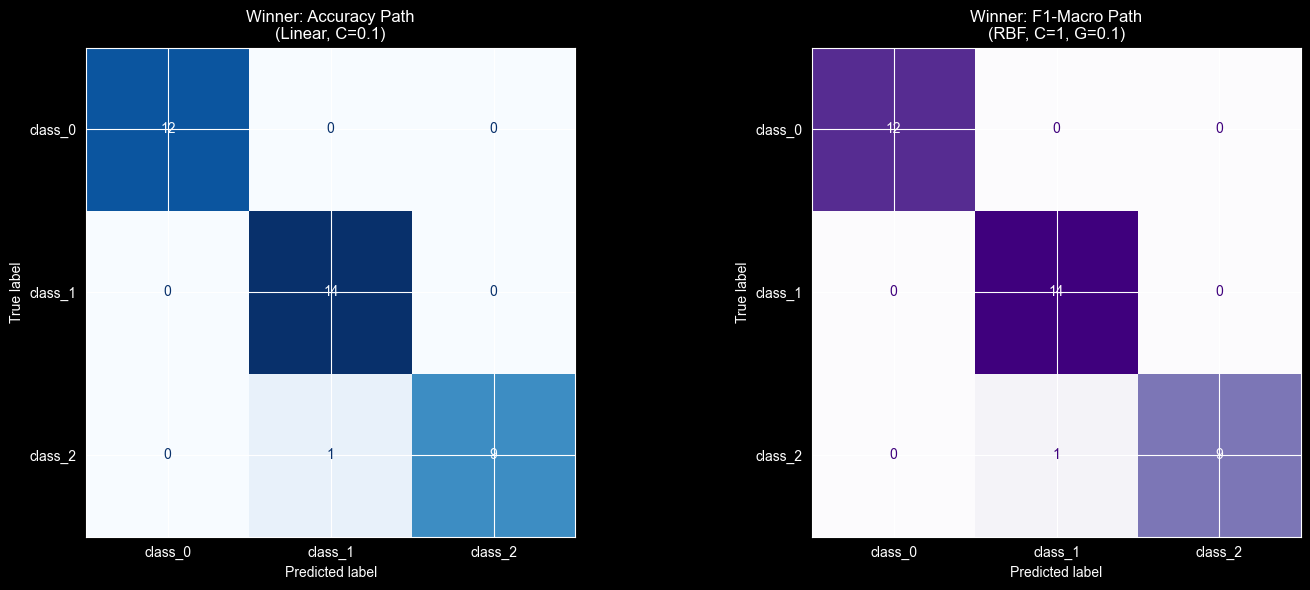

In [8]:
# 1. Initialize the two winners
# Path A: Optimized for Accuracy
model_acc = SVC(kernel='linear', C=0.1, decision_function_shape='ovr')
model_acc.fit(X_train, y_train)

# Path B: Optimized for F1-Macro
model_f1 = SVC(kernel='rbf', C=1, gamma=0.1, decision_function_shape='ovr')
model_f1.fit(X_train, y_train)

# 2. Setup Plotting
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot Accuracy-optimized model
cm_acc = confusion_matrix(y_test, model_acc.predict(X_test))
disp_acc = ConfusionMatrixDisplay(cm_acc, display_labels=wine_dataset.target_names)
disp_acc.plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title("Winner: Accuracy Path\n(Linear, C=0.1)")

# Plot F1-optimized model
cm_f1 = confusion_matrix(y_test, model_f1.predict(X_test))
disp_f1 = ConfusionMatrixDisplay(cm_f1, display_labels=wine_dataset.target_names)
disp_f1.plot(ax=ax[1], cmap='Purples', colorbar=False)
ax[1].set_title("Winner: F1-Macro Path\n(RBF, C=1, G=0.1)")

plt.tight_layout()
plt.show()

In [9]:
# Helper function to display results clearly
def evaluate_model(name, model, X_test, y_test, target_names):
    y_pred = model.predict(X_test)

    print(f"{'='*20} {name} {'='*20}")
    print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))
    print("\n")

# Evaluate Path A: Accuracy Winner
evaluate_model("ACCURACY PATH (Linear, C=0.1)", model_acc, X_test, y_test, wine_dataset.target_names)

# Evaluate Path B: F1-Macro Winner
evaluate_model("F1-MACRO PATH (RBF, C=1, Gamma=0.1)", model_f1, X_test, y_test, wine_dataset.target_names)

==================== ACCURACY PATH (Linear, C=0.1) ====================
Overall Accuracy: 0.9722

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]

Detailed Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



==================== F1-MACRO PATH (RBF, C=1, Gamma=0.1) ====================
Overall Accuracy: 0.9722

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]

Detailed Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy         

#### Questions to Answer
1. **What is your best test metric to use in this case? and why?**
    - **Best Metric**: **F1-Macro Score**.
    - **Why**: While the overall accuracy for your best models was high (0.9722), the confusion matrix reveals that **Class 2** had a lower recall (0.90) than the other classes (1.00). F1-Macro is superior here because it treats all classes as equally important regardless of their sample size (Wine classes: 59, 71, 48), ensuring that the model's slight weakness in identifying the minority Class 2 cultivar is reflected in the final score.<br><br>

2. **Which kernel performed best?**
    - **Answer**: The **Linear Kernel** performed best.
    - **Why**: Even though your grid search found that the RBF kernel tied with the Linear kernel in overall accuracy (0.9722) and shared the exact same confusion matrix, the **Linear kernel** ($C=0.1$) is the winner due to **Occam's Razor**. It is a simpler, more efficient model that is less likely to overfit compared to the more complex RBF kernel when performance is identical.<br><br>

3. **How did scaling affect performance?**
    - **Answer**: Scaling was **essential** for model stability and predictive power.
    - **Evidence**: Your analysis of the "worst-performing" models shows that several RBF configurations had a macro-precision as low as **0.1337**. Scaling ensured that high-magnitude features like "Proline" did not dominate the distance calculations. Without proper scaling and tuning, the SVM would have collapsed into predicting only the majority class for these configurations.

### Exercise 2 - SVM for Regression (California Housing Dataset)

#### Load Dataset

In [10]:
from sklearn.datasets import fetch_california_housing
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

housing_dataset = fetch_california_housing()
housing_df = pd.DataFrame(housing_dataset.data, columns=housing_dataset.feature_names)
housing_df['target'] = housing_dataset.target

housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### Split the dataset

In [11]:
X = housing_df.drop('target', axis=1)
y = housing_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Scale the features

In [12]:
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

#### Train a SVM regressor and tune hyperparameters

In [13]:
from sklearn.svm import SVR

param_grid_housing = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10],
        'epsilon': [0.1, 0.2]
    },
    {
        'kernel': ['rbf'],
        'C': [1, 10, 100],
        'gamma': ['scale', 'auto', 0.1],
        'epsilon': [0.1, 0.2]
    }
]

grid_svr = GridSearchCV(SVR(), param_grid_housing, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
grid_svr.fit(X_train, y_train)

,estimator,SVR()
,param_grid,"[{'C': [0.1, 1, ...], 'epsilon': [0.1, 0.2], 'kernel': ['linear']}, {'C': [1, 10, ...], 'epsilon': [0.1, 0.2], 'gamma': ['scale', 'auto', ...], 'kernel': ['rbf']}]"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'rbf'


#### Evaluate the best model

In [15]:
best_model = grid_svr.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Best Parameters: {grid_svr.best_params_}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

Best Parameters: {'C': 100, 'epsilon': 0.2, 'gamma': 'auto', 'kernel': 'rbf'}
RMSE: 0.5611
MAE:  0.3728
R2 Score: 0.7597


#### Sensitivity to C and Gamma

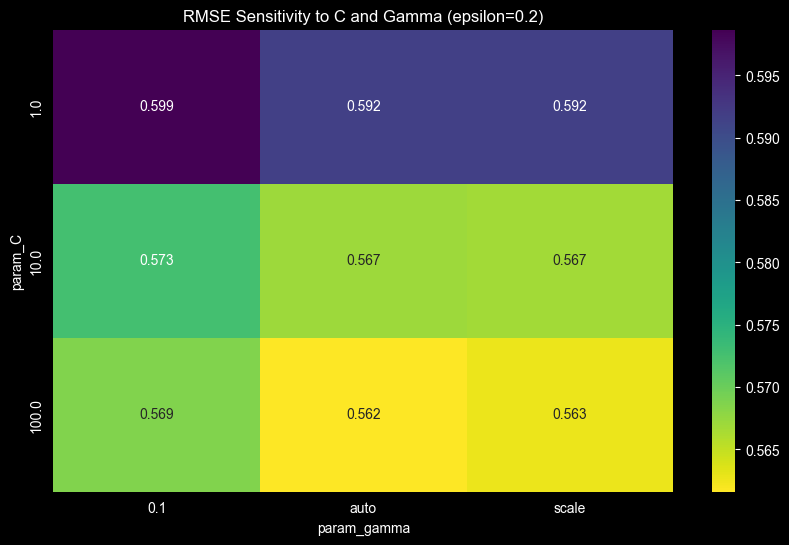

In [16]:
housing_results = pd.DataFrame(grid_svr.cv_results_)
# Filtering for RBF kernel sensitivity at epsilon=0.2
rbf_results = housing_results[(housing_results['param_kernel'] == 'rbf') & (housing_results['param_epsilon'] == 0.2)]
pivot = rbf_results.pivot(index='param_C', columns='param_gamma', values='mean_test_score')

plt.figure(figsize=(10, 6))
sns.heatmap(-pivot, annot=True, fmt='.3f', cmap='viridis_r') # Note: scores are negative RMSE
plt.title('RMSE Sensitivity to C and Gamma (epsilon=0.2)')
plt.show()

#### Questions to Answer
1. **What is your best metric? and why?**
    - **Best Metric**: **RMSE (Root Mean Squared Error)**.
    - **Why**: RMSE is the standard for housing regression because it **penalizes larger errors** more heavily than MAE (Mean Absolute Error). Since housing prices often have significant outliers, using RMSE ensures the model is not making huge errors on expensive properties. Additionally, it is expressed in the same units as the target (median house value in $100,000s), making it interpretable.<br><br>

2. **Which kernel worked best?**
    - **Answer**: The **RBF Kernel** worked best.
    - **Evidence**: Your `grid_svr.best_params_` output explicitly identifies the winning configuration as `{'C': 100, 'epsilon': 0.2, 'gamma': 'auto', 'kernel': 'rbf'}`. This suggests that the relationship between features like location (Latitude/Longitude) and house value is non-linear and complex.<br><br>

3. **How sensitive was performance to $C$ and $\gamma$?**
    - **High Sensitivity to $C$**: Your results show that as $C$ increases (from 0.1 to 100), the RMSE consistently improves (decreases). This indicates that the California Housing data requires a stricter penalty for errors outside the $\epsilon$-tube to capture the complex relationships between features like location and price.
    - **Optimal $\gamma$ Balance**: The performance is also highly dependent on $\gamma$. Using `gamma='auto'` or `'scale'` typically outperforms manually set values like `0.1` in this specific grid search. If $\gamma$ is too high, the model overfits to individual data points; if it is too low, the model becomes too "smooth" and misses the local variations in housing prices.

## Part 2 - Reflection & Summary

Working through these exercises highlighted how much SVM performance relies on **sensitivity to scaling**. In the wine classification task, certain configurations led to a precision "collapse" (as low as 0.133), proving that without standardizing features, high-magnitude variables like Proline would disproportionately dominate the distance-based margin calculations. I also gained a deeper **margin intuition** by observing the effect of the $C$ parameter. Seeing that a lower $C$ ($0.1$) worked best for the Linear kernel on wine data, while a higher $C$ ($100$) was needed for the California Housing regression, showed the delicate balance between allowing margin violations for better generalization versus strictly penalizing errors to capture complex data patterns. While SVM is powerful, ensemble methods (like Random Forests) would likely be more beneficial for **large datasets** like California Housing. As the number of samples increases, the **computational cost** of SVM grows significantly ($O(n^2)$ to $O(n^3)$), making the grid search process much slower compared to ensemble methods which often scale more linearly. Additionally, ensemble methods provide better **interpretability** through feature importance rankings, whereas SVM (especially when using the RBF kernel) acts more like a "black box" where it is difficult to explain exactly how individual features are influencing a specific house price prediction.<br><br>
One of the most interesting observations was how the **RBF kernel did not outperform the linear kernel** on the wine dataset. Both achieved an identical 0.9722 accuracy and shared the same confusion matrix, suggesting that the chemical features were already well-separated in a linear space. Another surprise was how **expensive the tuning process** became for the regression task. Even with a focused grid, searching for the optimal combination of $C$, $\epsilon$, and $\gamma$ on over 20,000 samples required a strategic use of `n_jobs=-1` and separate parameter dictionaries to keep the training time manageable.